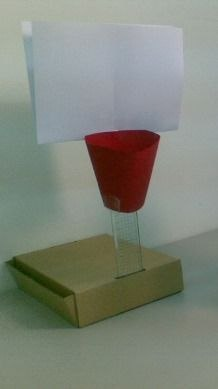

In [88]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image = cv2.imread('/content/Bucket.jpg')
#redrgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()


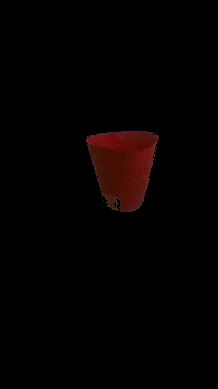

In [89]:
upperred= np.array([50,45,255])
lowerred=np.array([0,0,40])
mask = cv2.inRange(image,lowerred, upperred)
maskcolour= cv2.bitwise_and(image,image,mask=mask)

cv2_imshow(maskcolour)

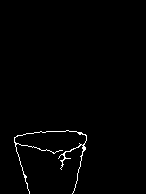

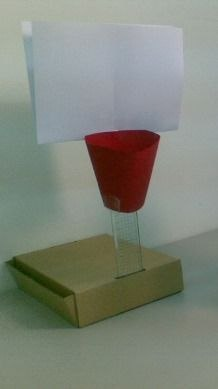

In [92]:
blurmask = cv2.bilateralFilter(maskcolour,5,10,2)
h,w,c= image.shape
copy_image = blurmask[0:h//2,w//3:w]
edgeblurmask= cv2.Canny(copy_image,0,100)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
edges_cleaned = cv2.morphologyEx(edgeblurmask, cv2.MORPH_CLOSE, kernel)
cv2_imshow(edges_cleaned)
cv2_imshow(image)

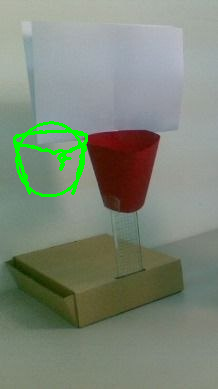

In [96]:
cont,heirachy= cv2.findContours(edges_cleaned,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(image,cont,-1,(0,255,0),2)
EllipseData=cv2.fitEllipse(max(cont, key = cv2.contourArea))
cv2.ellipse(image, EllipseData,(0,255,0),2)

cv2_imshow(image)
cv2.waitKey()
cv2.destroyAllWindows()